In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        dirs[:] = []
    for f in files[:10]:
        print(f"{indent}  {f}")

In [ ]:
!git clone https://github.com/ivanlamadrid/Tesis_CXR.git

In [ ]:
%cd /kaggle/working/Tesis_CXR

In [ ]:
import os
from pathlib import Path

for path in Path("/kaggle/input").rglob("*Data*2017*.csv"):
    print(path)

In [ ]:
from pathlib import Path

pngs = list(Path("/kaggle/input").rglob("*.png"))
print("Total PNG encontrados:", len(pngs))
print(pngs[:5])

In [ ]:
!mkdir -p /kaggle/working/processed

In [ ]:
!python scripts/prepare_nih_multilabel.py \
  --metadata-csv /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv \
  --images-root /kaggle/input/nih-chest-xrays/data \
  --output-csv /kaggle/working/processed/nih_multilabel.csv \
  --recursive-image-search

In [ ]:
%cd /kaggle/working/Tesis_CXR
!git pull

In [ ]:
!python scripts/prepare_nih_multilabel.py \
  --metadata-csv /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv \
  --images-root /kaggle/input/datasets/organizations/nih-chest-xrays/data \
  --output-csv /kaggle/working/processed/nih_multilabel.csv \
  --recursive-image-search

In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/working/processed/nih_multilabel.csv")

print("Shape:", df.shape)
print("No Finding es columna:", "No Finding" in df.columns)
print("Pleural Thickening es columna:", "Pleural Thickening" in df.columns)
print("Pleural_Thickening es columna:", "Pleural_Thickening" in df.columns)

df.head()

In [ ]:
!python scripts/create_patient_splits.py \
  --input-csv /kaggle/working/processed/nih_multilabel.csv \
  --output-dir /kaggle/working/processed/splits

In [ ]:
import pandas as pd

base = "/kaggle/working/processed"

train = pd.read_csv(f"{base}/splits/train.csv")
val = pd.read_csv(f"{base}/splits/val.csv")
test = pd.read_csv(f"{base}/splits/test.csv")

train_patients = set(train["Patient ID"])
val_patients = set(val["Patient ID"])
test_patients = set(test["Patient ID"])

print("train:", train.shape)
print("val:", val.shape)
print("test:", test.shape)

print("Train ∩ Val:", len(train_patients & val_patients))
print("Train ∩ Test:", len(train_patients & test_patients))
print("Val ∩ Test:", len(val_patients & test_patients))

In [ ]:
!cd /kaggle/working && zip -r processed_phase2.zip processed

In [ ]:
!pip install -q torch torchvision

In [ ]:
import json
import pandas as pd
from pathlib import Path

labels_path = "/kaggle/working/Tesis_CXR/artifacts/labels.json"
train_csv = "/kaggle/working/processed/splits/train.csv"

with open(labels_path, "r", encoding="utf-8") as f:
    labels = json.load(f)

train_df = pd.read_csv(train_csv)

print("Labels:", labels)
print("Número de etiquetas:", len(labels))
print("Train shape:", train_df.shape)
print("Primera imagen existe:", Path(train_df.iloc[0]["image_path"]).exists())
print("No Finding es columna:", "No Finding" in train_df.columns)

In [ ]:
from src.datasets.nih_dataset import NIHMultilabelDataset
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = NIHMultilabelDataset(
    csv_path="/kaggle/working/processed/splits/train.csv",
    labels=labels,
    transform=transform,
)

print("Dataset length:", len(dataset))

image, target, metadata = dataset[0]

print("Image shape:", image.shape)
print("Target shape:", target.shape)
print("Target:", target)
print("Metadata:", metadata)

In [ ]:
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)

images, targets, metadata = next(iter(loader))

print("Batch images:", images.shape)
print("Batch targets:", targets.shape)
print("Targets dtype:", targets.dtype)

In [ ]:
%cd /kaggle/working/Tesis_CXR
!git pull

In [ ]:
!python scripts/check_dataset.py \
  --csv-path /kaggle/working/processed/splits/train.csv \
  --labels-json artifacts/labels.json \
  --batch-size 8 \
  --num-workers 2

In [ ]:
import torch

print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i), torch.cuda.get_device_capability(i))

In [ ]:
import torch

print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i), torch.cuda.get_device_capability(i))

In [1]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i), torch.cuda.get_device_capability(i))

Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA disponible: True
GPU count: 2
0 Tesla T4 (7, 5)
1 Tesla T4 (7, 5)


In [4]:
%cd /kaggle/working
!git clone https://github.com/ivanlamadrid/Tesis_CXR.git
%cd /kaggle/working/Tesis_CXR

/kaggle/working
Cloning into 'Tesis_CXR'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 124 (delta 30), reused 111 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 38.44 KiB | 1.54 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/kaggle/working/Tesis_CXR


In [5]:
!mkdir -p /kaggle/working/processed

!python scripts/prepare_nih_multilabel.py \
  --metadata-csv /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv \
  --images-root /kaggle/input/datasets/organizations/nih-chest-xrays/data \
  --output-csv /kaggle/working/processed/nih_multilabel.csv \
  --recursive-image-search

!python scripts/create_patient_splits.py \
  --input-csv /kaggle/working/processed/nih_multilabel.csv \
  --output-dir /kaggle/working/processed/splits

^C
Traceback (most recent call last):
  File "/kaggle/working/Tesis_CXR/scripts/prepare_nih_multilabel.py", line 211, in <module>
    main()
  File "/kaggle/working/Tesis_CXR/scripts/prepare_nih_multilabel.py", line 200, in main
    df = attach_image_paths(df, images_root, args.recursive_image_search)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/Tesis_CXR/scripts/prepare_nih_multilabel.py", line 116, in attach_image_paths
    image_index = build_recursive_image_index(images_root, image_names)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/Tesis_CXR/scripts/prepare_nih_multilabel.py", line 94, in build_recursive_image_index
    if not image_path.is_file() or image_path.name not in image_names:
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/pathlib.py", line 892, in is_file
    return S_ISREG(self.stat().st_mode)
                   ^^^^^^^^^^^
  File "/usr/lib/python3.12/pat

In [13]:
from pathlib import Path

root = Path("/kaggle/input/datasets/organizations/nih-chest-xrays/data")

pngs = []
for folder in sorted(root.glob("images_*/images")):
    found = list(folder.glob("*.png"))
    print(folder.name, len(found))
    pngs.extend(found)

print("Total PNG:", len(pngs))
print("Primer PNG:", pngs[0] if pngs else None)

images 4999
images 10000
images 10000
images 10000
images 10000
images 10000
images 10000
images 10000
images 10000
images 10000
images 10000
images 7121
Total PNG: 112120
Primer PNG: /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000502_003.png


In [14]:
%cd /kaggle/working/Tesis_CXR
!git pull

/kaggle/working/Tesis_CXR
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.12 KiB | 1.12 MiB/s, done.
From https://github.com/ivanlamadrid/Tesis_CXR
   c7639b2..c9eb73f  main       -> origin/main
Updating c7639b2..c9eb73f
Fast-forward
 scripts/prepare_nih_multilabel.py | 77 ++++++++++++++++++++++++++++++++++-----
 1 file changed, 67 insertions(+), 10 deletions(-)


In [15]:
!rm -rf /kaggle/working/processed
!mkdir -p /kaggle/working/processed

!python scripts/prepare_nih_multilabel.py \
  --metadata-csv /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv \
  --images-root /kaggle/input/datasets/organizations/nih-chest-xrays/data \
  --output-csv /kaggle/working/processed/nih_multilabel.csv \
  --recursive-image-search

[image-index] start: expected=112120 indexed=0 missing=112120
[image-index] after direct folder scan: expected=112120 indexed=0 missing=112120
[image-index] after images_*/images scan: expected=112120 indexed=112120 missing=0
[image-index] final: expected=112120 indexed=112120 missing=0
NIH multilabel preparation summary
Total rows: 112120
Unique patients: 30805
Existing images: 112120
Missing images: 0
No Finding rows: 60361
Positive count by label:
  Atelectasis: 11559
  Cardiomegaly: 2776
  Effusion: 13317
  Infiltration: 19894
  Mass: 5782
  Nodule: 6331
  Pneumonia: 1431
  Pneumothorax: 5302
  Consolidation: 4667
  Edema: 2303
  Emphysema: 2516
  Fibrosis: 1686
  Pleural Thickening: 3385
  Hernia: 227
Saved: /kaggle/working/processed/nih_multilabel.csv


In [16]:
from pathlib import Path

print(Path("/kaggle/working/processed/nih_multilabel.csv").exists())

True


In [17]:
!python scripts/create_patient_splits.py \
  --input-csv /kaggle/working/processed/nih_multilabel.csv \
  --output-dir /kaggle/working/processed/splits

NIH patient-level split summary
train:
  images: 78935
  patients: 21564
  positive count by label:
    Atelectasis: 8193
    Cardiomegaly: 1940
    Effusion: 9227
    Infiltration: 14030
    Mass: 4101
    Nodule: 4499
    Pneumonia: 990
    Pneumothorax: 3787
    Consolidation: 3262
    Edema: 1633
    Emphysema: 1922
    Fibrosis: 1191
    Pleural Thickening: 2377
    Hernia: 172
val:
  images: 16876
  patients: 4621
  positive count by label:
    Atelectasis: 1751
    Cardiomegaly: 402
    Effusion: 2031
    Infiltration: 2985
    Mass: 815
    Nodule: 902
    Pneumonia: 251
    Pneumothorax: 663
    Consolidation: 725
    Edema: 318
    Emphysema: 269
    Fibrosis: 243
    Pleural Thickening: 477
    Hernia: 27
test:
  images: 16309
  patients: 4620
  positive count by label:
    Atelectasis: 1615
    Cardiomegaly: 434
    Effusion: 2059
    Infiltration: 2879
    Mass: 866
    Nodule: 930
    Pneumonia: 190
    Pneumothorax: 852
    Consolidation: 680
    Edema: 352
    Emphysema

In [18]:
from pathlib import Path

print("train:", Path("/kaggle/working/processed/splits/train.csv").exists())
print("val:", Path("/kaggle/working/processed/splits/val.csv").exists())
print("test:", Path("/kaggle/working/processed/splits/test.csv").exists())

train: True
val: True
test: True


In [19]:
!python scripts/check_dataset.py \
  --csv-path /kaggle/working/processed/splits/train.csv \
  --labels-json artifacts/labels.json \
  --batch-size 8 \
  --num-workers 2

NIH PyTorch dataset check
Dataset size: 78935
Number of labels: 14
Sample image shape: [3, 224, 224]
Sample target shape: [14]
Sample metadata: {'image_path': '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000003_000.png', 'image_index': '00000003_000.png', 'patient_id': np.int64(3), 'finding_labels': 'Hernia'}
Batch images shape: [8, 3, 224, 224]
Batch targets shape: [8, 14]
Batch metadata keys: ['image_path', 'image_index', 'patient_id', 'finding_labels']
Positive count by label:
  Atelectasis: 8193
  Cardiomegaly: 1940
  Effusion: 9227
  Infiltration: 14030
  Mass: 4101
  Nodule: 4499
  Pneumonia: 990
  Pneumothorax: 3787
  Consolidation: 3262
  Edema: 1633
  Emphysema: 1922
  Fibrosis: 1191
  Pleural Thickening: 2377
  Hernia: 172
OK: "No Finding" is absent from labels and CSV columns.


In [20]:
!mkdir -p /kaggle/working/artifacts_baseline_smoke

!python scripts/train_baseline.py \
  --train-csv /kaggle/working/processed/splits/train.csv \
  --val-csv /kaggle/working/processed/splits/val.csv \
  --labels-json artifacts/labels.json \
  --output-dir /kaggle/working/artifacts_baseline_smoke \
  --epochs 1 \
  --batch-size 32 \
  --num-workers 2 \
  --lr 1e-4 \
  --image-size 224 \
  --device auto

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|███████████████████████████████████████| 30.8M/30.8M [00:00<00:00, 139MB/s]
DenseNet121 baseline training
Train rows: 78935
Val rows: 16876
Labels: 14
Device: cuda
Pretrained ImageNet: True
^C
Traceback (most recent call last):
  File "/kaggle/working/Tesis_CXR/scripts/train_baseline.py", line 287, in <module>
    main()
  File "/kaggle/working/Tesis_CXR/scripts/train_baseline.py", line 211, in main
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/Tesis_CXR/src/training/train_loop.py", line 23, in train_one_epoch
    logits = model(images)
             ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*ar

In [21]:
import pandas as pd
from pathlib import Path

processed = Path("/kaggle/working/processed")
smoke_dir = processed / "splits_smoke"
smoke_dir.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(processed / "splits/train.csv")
val = pd.read_csv(processed / "splits/val.csv")

train_smoke = train.sample(n=5000, random_state=42)
val_smoke = val.sample(n=1000, random_state=42)

train_smoke.to_csv(smoke_dir / "train_smoke.csv", index=False)
val_smoke.to_csv(smoke_dir / "val_smoke.csv", index=False)

print("train_smoke:", train_smoke.shape)
print("val_smoke:", val_smoke.shape)
print("Saved in:", smoke_dir)

train_smoke: (5000, 28)
val_smoke: (1000, 28)
Saved in: /kaggle/working/processed/splits_smoke


In [22]:
!ls -lh /kaggle/working/artifacts_baseline_smoke

total 0


In [23]:
%cd /kaggle/working/Tesis_CXR

/kaggle/working/Tesis_CXR


In [24]:
!rm -rf /kaggle/working/artifacts_baseline_smoke
!mkdir -p /kaggle/working/artifacts_baseline_smoke

!python scripts/train_baseline.py \
  --train-csv /kaggle/working/processed/splits_smoke/train_smoke.csv \
  --val-csv /kaggle/working/processed/splits_smoke/val_smoke.csv \
  --labels-json artifacts/labels.json \
  --output-dir /kaggle/working/artifacts_baseline_smoke \
  --epochs 1 \
  --batch-size 32 \
  --num-workers 2 \
  --lr 1e-4 \
  --image-size 224 \
  --device auto

DenseNet121 baseline training
Train rows: 5000
Val rows: 1000
Labels: 14
Device: cuda
Pretrained ImageNet: True
epoch=1 train_loss=0.254117 val_loss=0.174651 macro_auc=0.696104 micro_auc=0.800435 f1_macro=0.014806
Saved best model: /kaggle/working/artifacts_baseline_smoke/baseline_densenet121_best.pt
Saved metrics: /kaggle/working/artifacts_baseline_smoke/baseline_metrics.json
Saved history: /kaggle/working/artifacts_baseline_smoke/baseline_training_history.csv


In [25]:
!ls -lh /kaggle/working/artifacts_baseline_smoke

total 28M
-rw-r--r-- 1 root root  28M May 19 01:49 baseline_densenet121_best.pt
-rw-r--r-- 1 root root 1.5K May 19 01:49 baseline_metrics.json
-rw-r--r-- 1 root root  155 May 19 01:49 baseline_training_history.csv


In [26]:
import json
import pandas as pd

with open("/kaggle/working/artifacts_baseline_smoke/baseline_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

print(json.dumps(metrics, indent=2))

history = pd.read_csv("/kaggle/working/artifacts_baseline_smoke/baseline_training_history.csv")
history

{
  "model_name": "baseline_densenet121",
  "best_epoch": 1,
  "best_val_loss": 0.17465119671821594,
  "best_macro_auc": 0.6961040749058024,
  "labels": [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural Thickening",
    "Hernia"
  ],
  "history": [
    {
      "epoch": 1,
      "train_loss": 0.2541166347026825,
      "val_loss": 0.17465119671821594,
      "macro_auc": 0.6961040749058024,
      "micro_auc": 0.800434532193296,
      "f1_macro": 0.01480586426315544
    }
  ],
  "best_metrics": {
    "auc_per_class": [
      0.7250040218790219,
      0.6599605151828524,
      0.8087275967584654,
      0.711993608490739,
      0.6529955569723656,
      0.6837972876516774,
      0.48135363790186125,
      0.7415746297808872,
      0.736484375,
      0.8764426340801086,
      0.7845454545454545,
      0.5756632653061224,
    

,epoch,train_loss,val_loss,macro_auc,micro_auc,f1_macro
0,1,0.254117,0.174651,0.696104,0.800435,0.014806


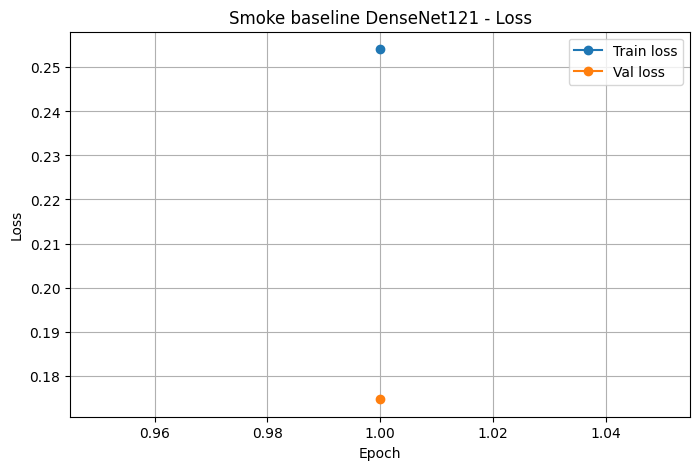

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("/kaggle/working/artifacts_baseline_smoke/baseline_training_history.csv")

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
plt.plot(history["epoch"], history["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Smoke baseline DenseNet121 - Loss")
plt.legend()
plt.grid(True)
plt.show()

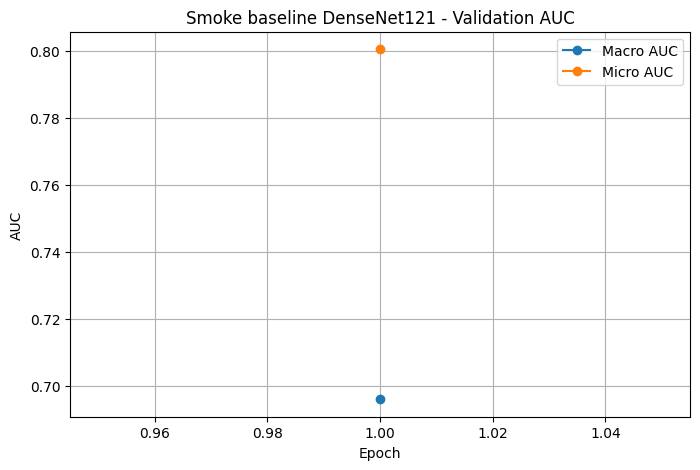

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["macro_auc"], marker="o", label="Macro AUC")
plt.plot(history["epoch"], history["micro_auc"], marker="o", label="Micro AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Smoke baseline DenseNet121 - Validation AUC")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
!cd /kaggle/working && zip -r baseline_smoke_artifacts.zip artifacts_baseline_smoke

  adding: artifacts_baseline_smoke/ (stored 0%)
  adding: artifacts_baseline_smoke/baseline_training_history.csv (deflated 26%)
  adding: artifacts_baseline_smoke/baseline_densenet121_best.pt (deflated 7%)
  adding: artifacts_baseline_smoke/baseline_metrics.json (deflated 57%)


In [30]:
!rm -rf /kaggle/working/artifacts_baseline_full_1epoch
!mkdir -p /kaggle/working/artifacts_baseline_full_1epoch

!python scripts/train_baseline.py \
  --train-csv /kaggle/working/processed/splits/train.csv \
  --val-csv /kaggle/working/processed/splits/val.csv \
  --labels-json artifacts/labels.json \
  --output-dir /kaggle/working/artifacts_baseline_full_1epoch \
  --epochs 1 \
  --batch-size 32 \
  --num-workers 2 \
  --lr 1e-4 \
  --image-size 224 \
  --device auto

DenseNet121 baseline training
Train rows: 78935
Val rows: 16876
Labels: 14
Device: cuda
Pretrained ImageNet: True
epoch=1 train_loss=0.162686 val_loss=0.148573 macro_auc=0.805540 micro_auc=0.864960 f1_macro=0.087269
Saved best model: /kaggle/working/artifacts_baseline_full_1epoch/baseline_densenet121_best.pt
Saved metrics: /kaggle/working/artifacts_baseline_full_1epoch/baseline_metrics.json
Saved history: /kaggle/working/artifacts_baseline_full_1epoch/baseline_training_history.csv


In [31]:
import json
import pandas as pd

metrics_path = "/kaggle/working/artifacts_baseline_full_1epoch/baseline_metrics.json"
history_path = "/kaggle/working/artifacts_baseline_full_1epoch/baseline_training_history.csv"

with open(metrics_path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

print(json.dumps(metrics, indent=2))

history = pd.read_csv(history_path)
history

{
  "model_name": "baseline_densenet121",
  "best_epoch": 1,
  "best_val_loss": 0.148572529581139,
  "best_macro_auc": 0.8055397057317514,
  "labels": [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural Thickening",
    "Hernia"
  ],
  "history": [
    {
      "epoch": 1,
      "train_loss": 0.1626859193586477,
      "val_loss": 0.148572529581139,
      "macro_auc": 0.8055397057317514,
      "micro_auc": 0.8649598438988989,
      "f1_macro": 0.08726927074835959
    }
  ],
  "best_metrics": {
    "auc_per_class": [
      0.7936551203326552,
      0.8366664915074984,
      0.8664947938147662,
      0.7044484896587176,
      0.8301603969223166,
      0.7098274232767937,
      0.7337504717970225,
      0.8539886014044369,
      0.7999739527177778,
      0.8852653261529322,
      0.8946267787377697,
      0.7935282356780451,


,epoch,train_loss,val_loss,macro_auc,micro_auc,f1_macro
0,1,0.162686,0.148573,0.80554,0.86496,0.087269


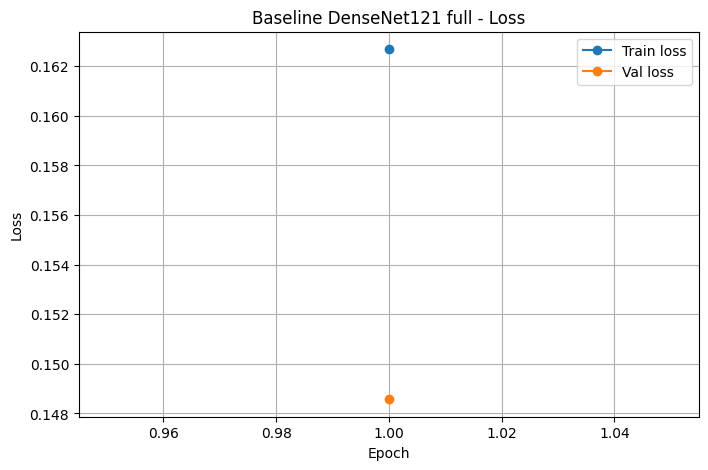

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("/kaggle/working/artifacts_baseline_full_1epoch/baseline_training_history.csv")

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
plt.plot(history["epoch"], history["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline DenseNet121 full - Loss")
plt.legend()
plt.grid(True)
plt.show()

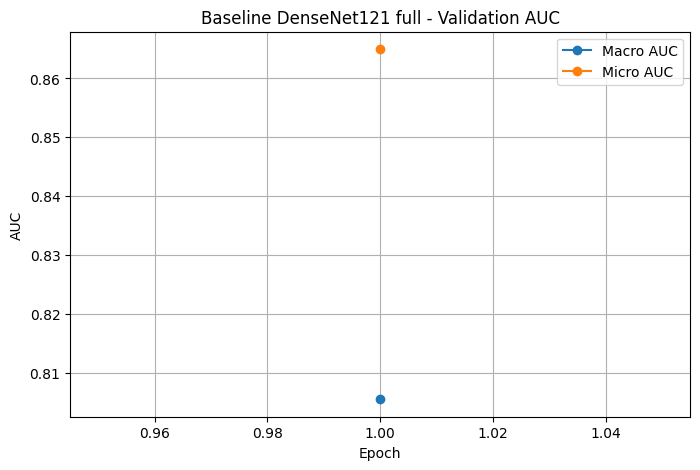

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["macro_auc"], marker="o", label="Macro AUC")
plt.plot(history["epoch"], history["micro_auc"], marker="o", label="Micro AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Baseline DenseNet121 full - Validation AUC")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
!cd /kaggle/working && zip -r baseline_full_1epoch_artifacts.zip artifacts_baseline_full_1epoch

  adding: artifacts_baseline_full_1epoch/ (stored 0%)
  adding: artifacts_baseline_full_1epoch/baseline_training_history.csv (deflated 27%)
  adding: artifacts_baseline_full_1epoch/baseline_densenet121_best.pt (deflated 7%)
  adding: artifacts_baseline_full_1epoch/baseline_metrics.json (deflated 57%)


In [35]:
!rm -rf /kaggle/working/artifacts_baseline_full_3epochs
!mkdir -p /kaggle/working/artifacts_baseline_full_3epochs

!python scripts/train_baseline.py \
  --train-csv /kaggle/working/processed/splits/train.csv \
  --val-csv /kaggle/working/processed/splits/val.csv \
  --labels-json artifacts/labels.json \
  --output-dir /kaggle/working/artifacts_baseline_full_3epochs \
  --epochs 3 \
  --batch-size 32 \
  --num-workers 2 \
  --lr 1e-4 \
  --image-size 224 \
  --device auto

DenseNet121 baseline training
Train rows: 78935
Val rows: 16876
Labels: 14
Device: cuda
Pretrained ImageNet: True
epoch=1 train_loss=0.162686 val_loss=0.148573 macro_auc=0.805540 micro_auc=0.864960 f1_macro=0.087269
epoch=2 train_loss=0.147420 val_loss=0.145730 macro_auc=0.824041 micro_auc=0.875686 f1_macro=0.126559
epoch=3 train_loss=0.142784 val_loss=0.145112 macro_auc=0.830172 micro_auc=0.877304 f1_macro=0.121212
Saved best model: /kaggle/working/artifacts_baseline_full_3epochs/baseline_densenet121_best.pt
Saved metrics: /kaggle/working/artifacts_baseline_full_3epochs/baseline_metrics.json
Saved history: /kaggle/working/artifacts_baseline_full_3epochs/baseline_training_history.csv
